# Figure 3: Dynamics of decision parameters across action costs.

## setup and imports

In [1]:
import fnmatch
import matplotlib.pyplot as plt
import numpy as np
import glob

from sessionlists import (dist60, dist90, dist120, TM20, TM10, TM2, TMrev2, TMrev10, TMrev20)
from utils import *
from plotting import *
from model_functions import *
from initialize_notebook import initialize_notebook

plt.style.use('./Figures/paper.mplstyle')

In [2]:
root, rat_lists, rat_markers, (example_rat, example_session), GENERAL_PLOT_PARAMS = initialize_notebook()
intact_rats, DSlesioned_rats, VSlesioned_rats, sham_rats, all_rats = rat_lists

alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))


Found 84 rats in the DATA folder
Listed 57 rats in total, of which 19 are intact (8♀, 11♂), 19 DS lesions, 15 VS lesions and 4 shams.
Example rat is RatM00, example session: RatM00_2021_07_22_16_13_03


In [3]:
dist_shuffled_slopes, dist_p_value_slope, dist_observed_slope = [], [], []
dist_shuffled_intercepts, dist_p_value_intercept, dist_observed_intercept = [], [], []
tm_shuffled_slopes, tm_p_value_slope, tm_observed_slope = [], [], []
tm_shuffled_intercepts, tm_p_value_intercept, tm_observed_intercept = [], [], []

vars = [alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u][::-1]
names = [r'$\alpha_0$', r'$\alpha_t$', r'$\alpha_U$', r'$\gamma_0$', r'$\gamma_t$', r'$\gamma_U$', r'$\mu_0$', r'$\mu_t$', r'$\mu_U$', r'$\sigma_0$', r'$\sigma_t$', r'$\sigma_U$'][::-1]
for var in vars:
    shuffled_slopes, p_value_slope, observed_slope, shuffled_intercepts, p_value_intercept, observed_intercept = compute_regression_permutation(var, dist_or_tm='dist', animal_list=intact_rats, num_iterations=10000)

    dist_shuffled_slopes.append(shuffled_slopes)
    dist_p_value_slope.append(p_value_slope)
    dist_observed_slope.append(observed_slope)
    dist_shuffled_intercepts.append(shuffled_intercepts)
    dist_p_value_intercept.append(p_value_intercept)
    dist_observed_intercept.append(observed_intercept)

    shuffled_slopes, p_value_slope, observed_slope, shuffled_intercepts, p_value_intercept, observed_intercept = compute_regression_permutation(var, dist_or_tm='tm', animal_list=intact_rats, num_iterations=10000)
    tm_shuffled_slopes.append(shuffled_slopes)
    tm_p_value_slope.append(p_value_slope)
    tm_observed_slope.append(observed_slope)
    tm_shuffled_intercepts.append(shuffled_intercepts)
    tm_p_value_intercept.append(p_value_intercept)
    tm_observed_intercept.append(observed_intercept)

p_s=0.103, p_i=0.000, obs_slope=0.004, obs_intercept=0.020
p_s=0.058, p_i=0.000, obs_slope=0.002, obs_intercept=0.020
p_s=0.759, p_i=0.001, obs_slope=-0.001, obs_intercept=0.006
p_s=0.882, p_i=0.000, obs_slope=0.000, obs_intercept=0.011
p_s=0.219, p_i=0.000, obs_slope=0.007, obs_intercept=0.087
p_s=0.007, p_i=0.000, obs_slope=0.007, obs_intercept=0.072
p_s=0.527, p_i=0.303, obs_slope=-0.004, obs_intercept=0.007
p_s=0.590, p_i=0.672, obs_slope=-0.001, obs_intercept=0.000
p_s=0.029, p_i=0.000, obs_slope=0.010, obs_intercept=0.047
p_s=0.107, p_i=0.000, obs_slope=0.003, obs_intercept=0.061
p_s=0.000, p_i=0.000, obs_slope=0.278, obs_intercept=0.870
p_s=0.000, p_i=0.000, obs_slope=0.054, obs_intercept=1.317
p_s=0.725, p_i=0.000, obs_slope=0.005, obs_intercept=-0.164
p_s=0.871, p_i=0.000, obs_slope=0.001, obs_intercept=-0.180
p_s=0.719, p_i=0.000, obs_slope=0.001, obs_intercept=-0.042
p_s=0.143, p_i=0.000, obs_slope=0.003, obs_intercept=-0.077
p_s=0.628, p_i=0.000, obs_slope=-0.021, obs_inter

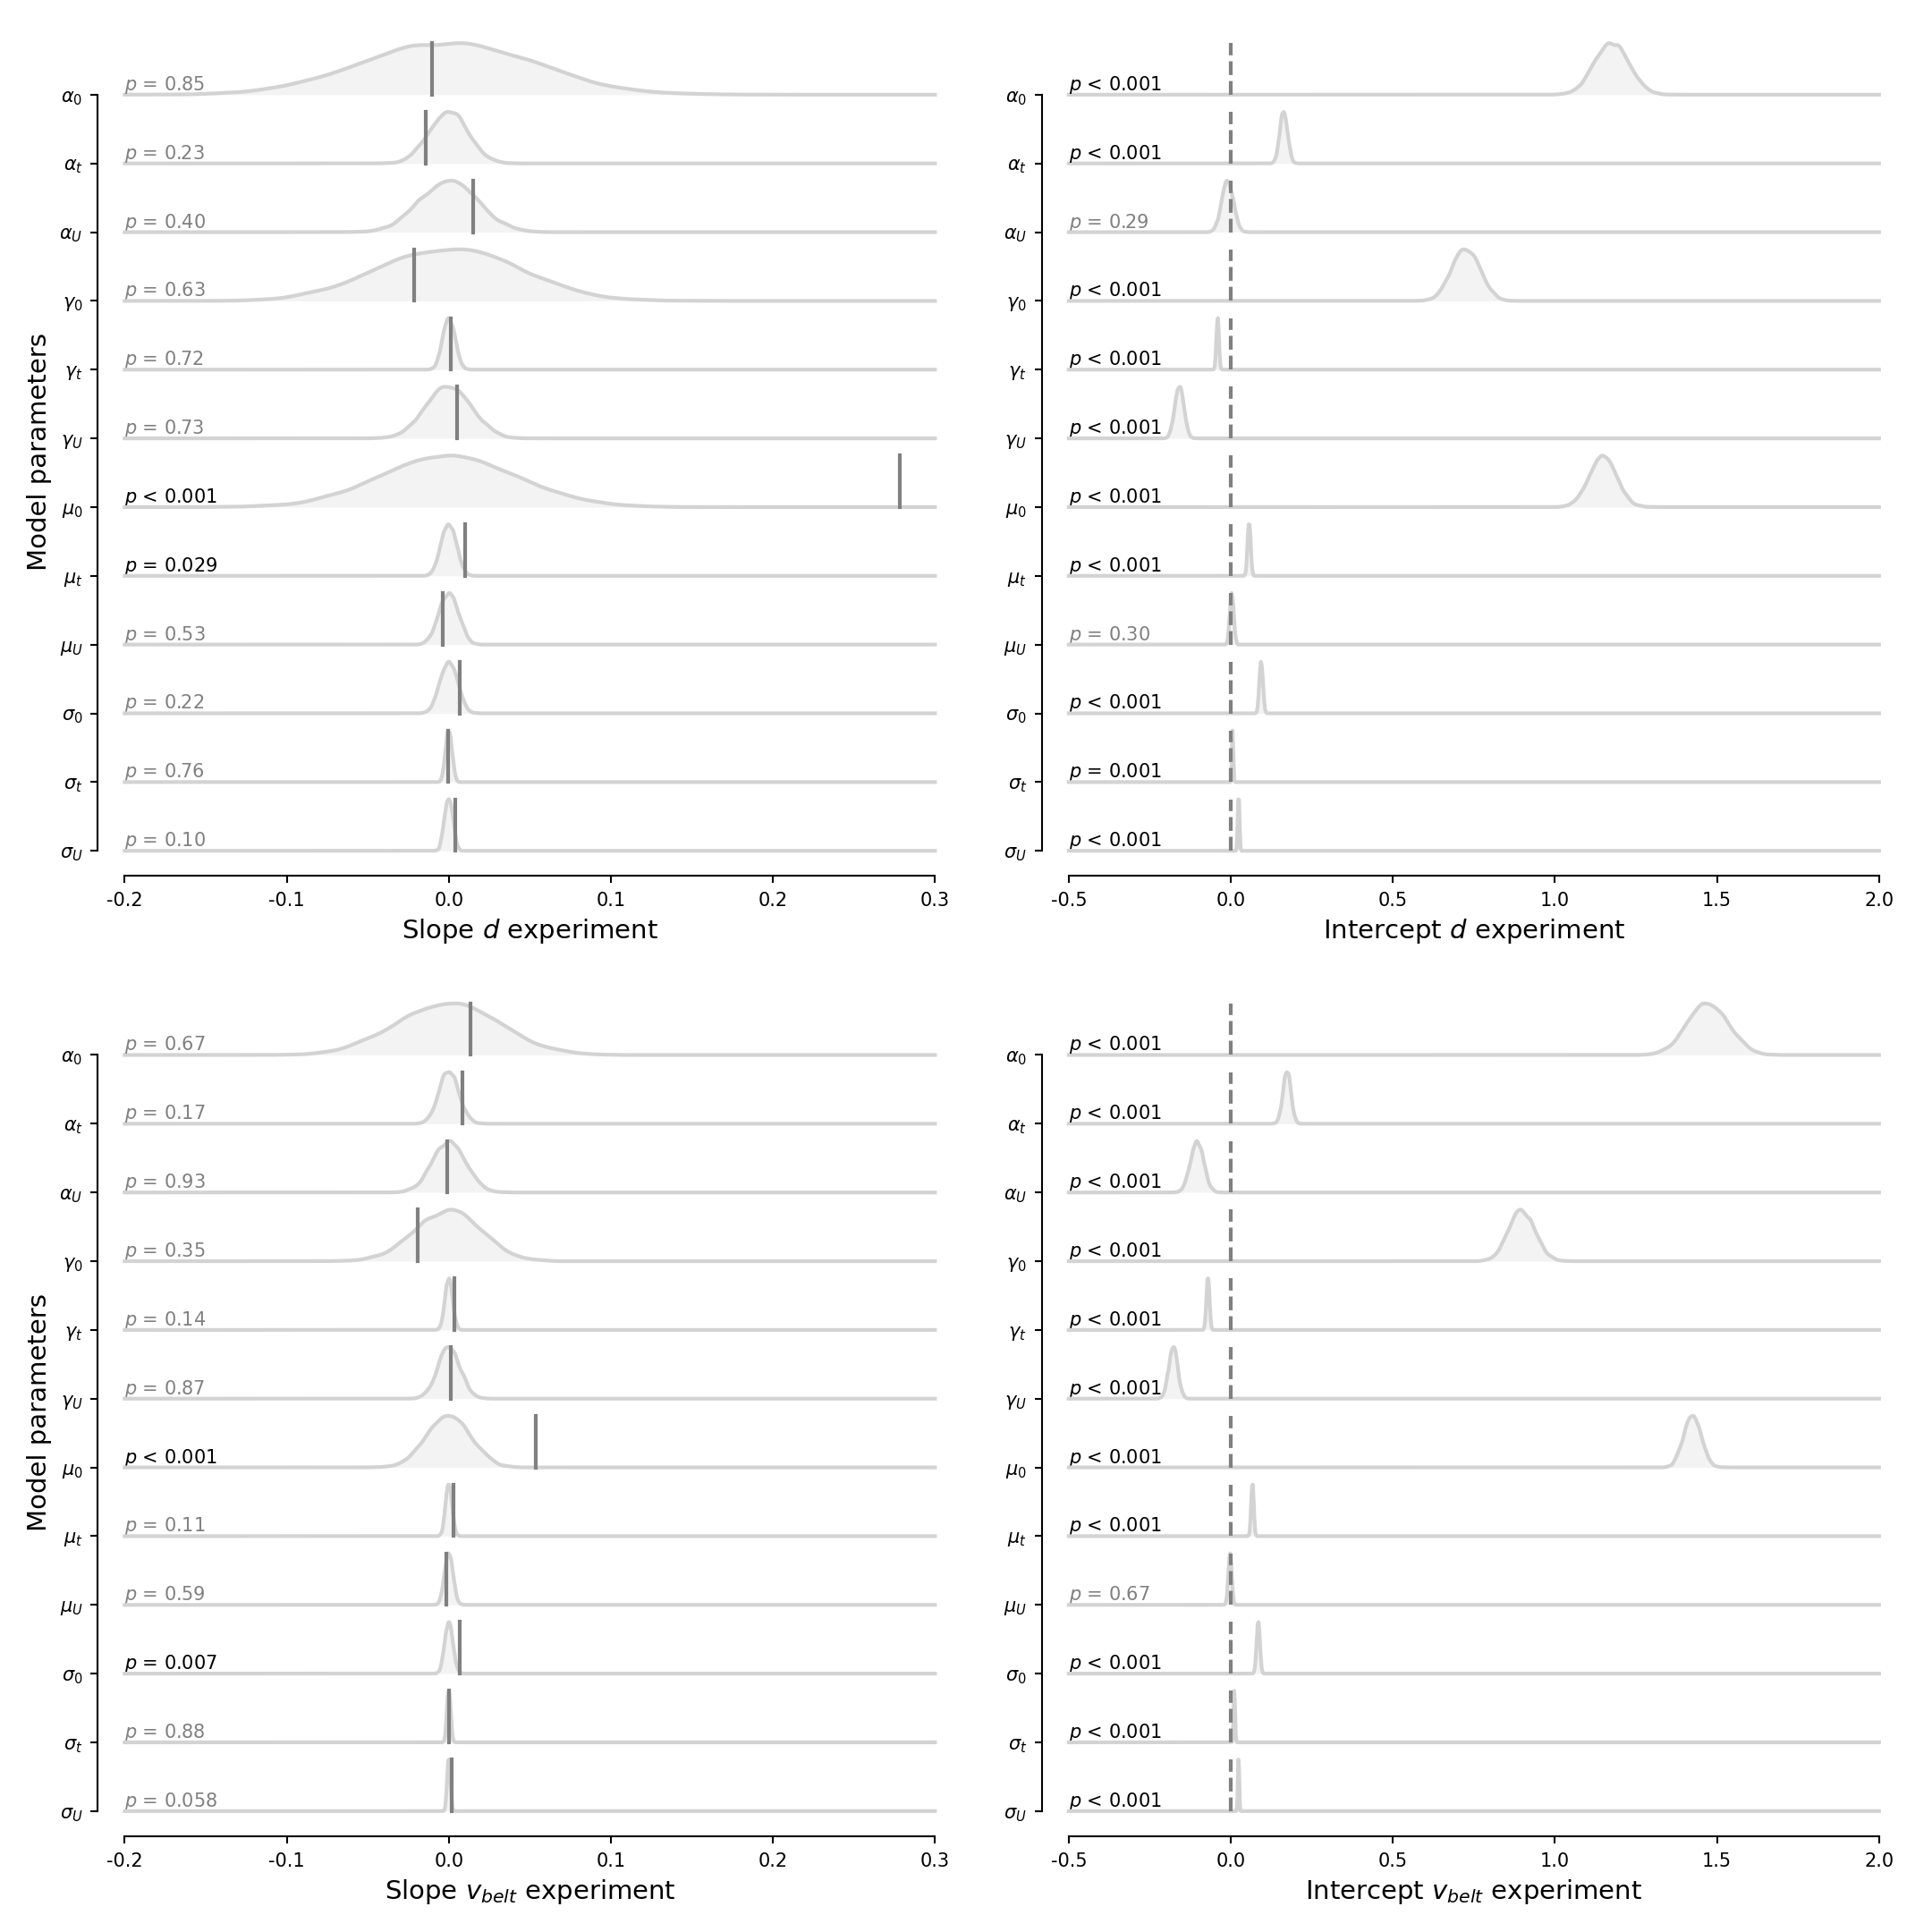

In [ ]:

fig, axs = plt.subplots(2, 2, figsize=(cm2inch(18), cm2inch(18)))
ridgeline(dist_shuffled_slopes, observed_vals=dist_observed_slope, pvals=dist_p_value_slope, overlap=.0, ax=axs[0, 0], labels=names, x_ticks=[-0.2, -0.1, 0, 0.1, 0.2, 0.3], ylabel='Model parameters', xlabel=r'Slope ($d$)')
ridgeline(dist_shuffled_intercepts, observed_vals=dist_observed_intercept, pvals=dist_p_value_intercept, overlap=.0, ax=axs[0, 1], labels=names, x_ticks=[-0.5, 0, 0.5, 1, 1.5, 2], show_zero=True, xlabel=r'Intercept ($d$)')
ridgeline(tm_shuffled_slopes, observed_vals=tm_observed_slope, pvals=tm_p_value_slope, overlap=.0, ax=axs[1, 0], labels=names, x_ticks=[-0.2, -0.1, 0, 0.1, 0.2, 0.3], ylabel='Model parameters', xlabel=r'Slope ($v_{\mathrm{belt}}$)')
ridgeline(tm_shuffled_intercepts, observed_vals=tm_observed_intercept, pvals=tm_p_value_intercept, overlap=.0, ax=axs[1, 1], labels=names, x_ticks=[-0.5, 0, 0.5, 1, 1.5, 2], show_zero=True, xlabel=r'Intercept ($v_{\mathrm{belt}}$)')


plt.savefig("./Figures_paper/Figure_SXXX.pdf", facecolor='w', 
        edgecolor='none', bbox_inches='tight', format="pdf", dpi=600)
plt.savefig("./Figures_paper/Figure_SXXX.svg", facecolor='w', 
        edgecolor='none', bbox_inches='tight', format="svg", dpi=600)